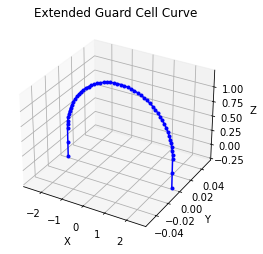

OBJ file saved as stomatal_guard_cells_with_extension.obj


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Base guard cell curve (without extra points)
def guard_cell_curve(t, curvature=1.5, extension_length=0.5):
    # Generate the base curve and shift it upward by extension_length.
    # This makes the endpoints be at z = cos(t) + extension_length.
    x = curvature * np.sin(t)
    y = np.zeros_like(t)
    z = np.cos(t) + extension_length  # Shift upward

    # Now, add extra points at the ends to provide the extension.
    # For the start, subtract extension_length so that it becomes 0.
    # For the end, subtract extension_length so that it becomes 0.
    x = np.concatenate(([x[0]], x, [x[-1]]))
    y = np.concatenate(([y[0]], y, [y[-1]]))
    z = np.concatenate(([z[0] - extension_length], z, [z[-1] - extension_length]))

    return np.array([x, y, z])


# Function to extend a curve at both ends by linearly interpolating extra points
def extend_curve_both_ends(curve, num_extra_points, extension_length):
    # curve is a 3 x N array
    first_point = curve[:, 0]
    last_point = curve[:, -1]
    extra_t = np.linspace(0, 1, num_extra_points + 1)[1:]  # exclude 0, include 1
    # At the start (t = -pi/2), we want to extend upward (positive z)
    extension_vector_start = np.array([0, 0, - extension_length])
    start_extension = first_point[:, None] + np.outer(extension_vector_start, extra_t)
    # At the end (t = pi/2), we want to extend downward (negative z)
    extension_vector_end = np.array([0, 0, - extension_length])
    end_extension = last_point[:, None] + np.outer(extension_vector_end, extra_t)
    # Concatenate: start extension, base curve, then end extension
    extended_curve = np.hstack((start_extension, curve, end_extension))
    return extended_curve

# Generate circular cross-section
def generate_circle(radius, num_points=20):
    theta = np.linspace(0, 2 * np.pi, num_points)
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    z = np.zeros_like(x)
    return np.array([x, y, z])

# Sweep the cross-section along the curve
def sweep_curve(curve, cross_section):
    num_curve_points = curve.shape[1]
    num_circle_points = cross_section.shape[1]
    swept_points = np.zeros((num_curve_points, num_circle_points, 3))
    for i in range(num_curve_points):
        point = curve[:, i]
        # Calculate tangent using neighbors; force horizontal tangent at endpoints
        if i == 0:
            tangent = curve[:, 1] - curve[:, 0]
        elif i == num_curve_points - 1:
            tangent = curve[:, -1] - curve[:, -2]
        else:
            tangent = curve[:, i+1] - curve[:, i-1]
        tangent = tangent / np.linalg.norm(tangent) if np.linalg.norm(tangent) != 0 else tangent
        # Use a fixed normal (pointing up) to help stabilize the cross-section orientation
        normal = np.array([0, 1, 0])
        binormal = np.cross(tangent, normal)
        binormal = binormal / np.linalg.norm(binormal)
        normal = np.cross(binormal, tangent)
        for j in range(num_circle_points):
            circle_point = cross_section[:, j]
            rotated_point = point + circle_point[0] * normal + circle_point[1] * binormal
            swept_points[i, j, :] = rotated_point
    return swept_points

### Set up parameters
curvature = 2.5
radius = 1
# Let extension length scale with the radius; adjust factor as needed:
extension_factor = 0.25
extension_length = extension_factor * radius
num_extra_points = 1  # Number of extra points to smoothly extend the curve

# Generate the base curve over t in [-pi/2, pi/2]
t = np.linspace(-np.pi/2, np.pi/2, 50)
base_curve = guard_cell_curve(t, curvature=curvature, extension_length=extension_length)
# Extend the curve at both ends
extended_curve = extend_curve_both_ends(base_curve, num_extra_points, extension_length)

# Visualize the extended curve
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(extended_curve[0], extended_curve[1], extended_curve[2], 'b.-')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Extended Guard Cell Curve')
plt.show()

# Generate the circular cross-section
circle = generate_circle(radius=radius, num_points=30)
# Sweep the cross-section along the extended curve to create a 3D mesh of one guard cell
guard_cell_mesh = sweep_curve(extended_curve, circle)

# Mirror the swept mesh across the Z-axis
mirror_guard_cell_mesh = np.copy(guard_cell_mesh)
mirror_guard_cell_mesh[:, :, 2] *= -1  # flip Z-coordinates
# Reverse the order along the sweep to keep face winding consistent
mirror_guard_cell_mesh = mirror_guard_cell_mesh[:, ::-1, :]

# Combine both halves (stacking the vertices)
combined_cells = np.vstack((guard_cell_mesh.reshape(-1, 3),
                              mirror_guard_cell_mesh.reshape(-1, 3)))

# Generate faces for the mesh
num_curve_points, num_circle_points, _ = guard_cell_mesh.shape
faces = []
# Faces for the first half
for i in range(num_curve_points - 1):
    for j in range(num_circle_points):
        v1 = i * num_circle_points + j + 1
        v2 = i * num_circle_points + (j + 1) % num_circle_points + 1
        v3 = (i + 1) * num_circle_points + j + 1
        v4 = (i + 1) * num_circle_points + (j + 1) % num_circle_points + 1
        faces.append([v1, v2, v4])
        faces.append([v1, v4, v3])
# Faces for the mirrored half, with offset
offset = num_curve_points * num_circle_points
for i in range(num_curve_points - 1):
    for j in range(num_circle_points):
        v1 = offset + i * num_circle_points + j + 1
        v2 = offset + i * num_circle_points + (j + 1) % num_circle_points + 1
        v3 = offset + (i + 1) * num_circle_points + j + 1
        v4 = offset + (i + 1) * num_circle_points + (j + 1) % num_circle_points + 1
        faces.append([v1, v2, v4])
        faces.append([v1, v4, v3])

# Save the combined mesh as an OBJ file
obj_filename = "stomatal_guard_cells_with_extension.obj"
with open(obj_filename, "w") as f:
    for vertex in combined_cells:
        f.write(f"v {vertex[0]} {vertex[1]} {vertex[2]}\n")
    for face in faces:
        f.write(f"f {face[0]} {face[1]} {face[2]}\n")

print(f"OBJ file saved as {obj_filename}")


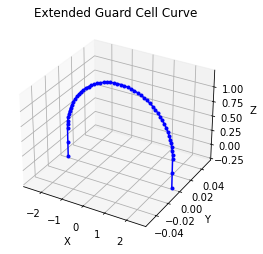

OBJ file saved as stomatal_guard_cell_with_extension.obj


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Base guard cell curve (without extra points)
def guard_cell_curve(t, curvature=1.5, extension_length=0.5):
    # Generate the base curve and shift it upward by extension_length.
    # This makes the endpoints be at z = cos(t) + extension_length.
    x = curvature * np.sin(t)
    y = np.zeros_like(t)
    z = np.cos(t) + extension_length  # Shift upward

    # Now, add extra points at the ends to provide the extension.
    # For the start, subtract extension_length so that it becomes 0.
    # For the end, subtract extension_length so that it becomes 0.
    x = np.concatenate(([x[0]], x, [x[-1]]))
    y = np.concatenate(([y[0]], y, [y[-1]]))
    z = np.concatenate(([z[0] - extension_length], z, [z[-1] - extension_length]))

    return np.array([x, y, z])


# Function to extend a curve at both ends by linearly interpolating extra points
def extend_curve_both_ends(curve, num_extra_points, extension_length):
    # curve is a 3 x N array
    first_point = curve[:, 0]
    last_point = curve[:, -1]
    extra_t = np.linspace(0, 1, num_extra_points + 1)[1:]  # exclude 0, include 1
    # At the start (t = -pi/2), we want to extend upward (positive z)
    extension_vector_start = np.array([0, 0, - extension_length])
    start_extension = first_point[:, None] + np.outer(extension_vector_start, extra_t)
    # At the end (t = pi/2), we want to extend downward (negative z)
    extension_vector_end = np.array([0, 0, - extension_length])
    end_extension = last_point[:, None] + np.outer(extension_vector_end, extra_t)
    # Concatenate: start extension, base curve, then end extension
    extended_curve = np.hstack((start_extension, curve, end_extension))
    return extended_curve

# Generate circular cross-section
def generate_circle(radius, num_points=20):
    theta = np.linspace(0, 2 * np.pi, num_points)
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    z = np.zeros_like(x)
    return np.array([x, y, z])

# Sweep the cross-section along the curve
def sweep_curve(curve, cross_section):
    num_curve_points = curve.shape[1]
    num_circle_points = cross_section.shape[1]
    swept_points = np.zeros((num_curve_points, num_circle_points, 3))
    for i in range(num_curve_points):
        point = curve[:, i]
        # Calculate tangent using neighbors; force horizontal tangent at endpoints
        if i == 0:
            tangent = curve[:, 1] - curve[:, 0]
        elif i == num_curve_points - 1:
            tangent = curve[:, -1] - curve[:, -2]
        else:
            tangent = curve[:, i+1] - curve[:, i-1]
        tangent = tangent / np.linalg.norm(tangent) if np.linalg.norm(tangent) != 0 else tangent
        # Use a fixed normal (pointing up) to help stabilize the cross-section orientation
        normal = np.array([0, 1, 0])
        binormal = np.cross(tangent, normal)
        binormal = binormal / np.linalg.norm(binormal)
        normal = np.cross(binormal, tangent)
        for j in range(num_circle_points):
            circle_point = cross_section[:, j]
            rotated_point = point + circle_point[0] * normal + circle_point[1] * binormal
            swept_points[i, j, :] = rotated_point
    return swept_points

### Set up parameters
curvature = 2.5
radius = 1
# Let extension length scale with the radius; adjust factor as needed:
extension_factor = 0.25
extension_length = extension_factor * radius
num_extra_points = 1  # Number of extra points to smoothly extend the curve

# Generate the base curve over t in [-pi/2, pi/2]
t = np.linspace(-np.pi/2, np.pi/2, 50)
base_curve = guard_cell_curve(t, curvature=curvature, extension_length=extension_length)
# Extend the curve at both ends
extended_curve = extend_curve_both_ends(base_curve, num_extra_points, extension_length)

# Visualize the extended curve
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(extended_curve[0], extended_curve[1], extended_curve[2], 'b.-')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Extended Guard Cell Curve')
plt.show()

# Generate the circular cross-section
circle = generate_circle(radius=radius, num_points=30)
# Sweep the cross-section along the extended curve to create a 3D mesh of one guard cell
guard_cell_mesh = sweep_curve(extended_curve, circle)

# Generate faces for the mesh
num_curve_points, num_circle_points, _ = guard_cell_mesh.shape
faces = []
for i in range(num_curve_points - 1):
    for j in range(num_circle_points):
        v1 = i * num_circle_points + j + 1
        v2 = i * num_circle_points + (j + 1) % num_circle_points + 1
        v3 = (i + 1) * num_circle_points + j + 1
        v4 = (i + 1) * num_circle_points + (j + 1) % num_circle_points + 1
        faces.append([v1, v2, v4])
        faces.append([v1, v4, v3])

# Add faces for the ends of the cell
# Start end
start_center = num_curve_points * num_circle_points + 1
faces.append([start_center] + [i + 1 for i in range(num_circle_points)])
# End end
end_center = num_curve_points * num_circle_points + 2
faces.append([end_center] + [num_curve_points * num_circle_points - i for i in range(num_circle_points)])

# Save the mesh as an OBJ file
obj_filename = "stomatal_guard_cell_with_extension.obj"
with open(obj_filename, "w") as f:
    for vertex in guard_cell_mesh.reshape(-1, 3):
        f.write(f"v {vertex[0]} {vertex[1]} {vertex[2]}\n")
    f.write(f"v 0 0 {extended_curve[2, 0]}\n")  # Start center vertex
    f.write(f"v 0 0 {extended_curve[2, -1]}\n")  # End center vertex
    for face in faces:
        f.write(f"f {' '.join(map(str, face))}\n")

print(f"OBJ file saved as {obj_filename}")

In [28]:
## Save as a PLY file instead
ply_filename = "stomatal_guard_cells_with_extension.ply"
with open(ply_filename, "w") as f:
    f.write("ply\n")
    f.write("format ascii 1.0\n")
    f.write(f"element vertex {combined_cells.shape[0]}\n")
    f.write("property float x\n")
    f.write("property float y\n")
    f.write("property float z\n")
    f.write(f"element face {len(faces)}\n")
    f.write("property list uchar int vertex_index\n")
    f.write("end_header\n")
    for vertex in combined_cells:
        f.write(f"{vertex[0]} {vertex[1]} {vertex[2]}\n")
    for face in faces:
        f.write(f"3 {face[0] - 1} {face[1] - 1} {face[2] - 1}\n")

print(f"PLY file saved as {ply_filename}")

PLY file saved as stomatal_guard_cells_with_extension.ply


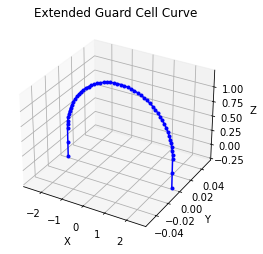

OBJ file saved as single_cell.obj
PLY file saved as single_cell.ply


In [31]:
## This code works for generating a single guard cell with a circular cross-section

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Base guard cell curve (without extra points)
def guard_cell_curve(t, curvature=1.5, extension_length=0.5):
    # Generate the base curve and shift it upward by extension_length.
    # This makes the endpoints be at z = cos(t) + extension_length.
    x = curvature * np.sin(t)
    y = np.zeros_like(t)
    z = np.cos(t) + extension_length  # Shift upward

    # Now, add extra points at the ends to provide the extension.
    # For the start, subtract extension_length so that it becomes 0.
    # For the end, subtract extension_length so that it becomes 0.
    x = np.concatenate(([x[0]], x, [x[-1]]))
    y = np.concatenate(([y[0]], y, [y[-1]]))
    z = np.concatenate(([z[0] - extension_length], z, [z[-1] - extension_length]))

    return np.array([x, y, z])


# Function to extend a curve at both ends by linearly interpolating extra points
def extend_curve_both_ends(curve, num_extra_points, extension_length):
    # curve is a 3 x N array
    first_point = curve[:, 0]
    last_point = curve[:, -1]
    extra_t = np.linspace(0, 1, num_extra_points + 1)[1:]  # exclude 0, include 1
    # At the start (t = -pi/2), we want to extend upward (positive z)
    extension_vector_start = np.array([0, 0, - extension_length])
    start_extension = first_point[:, None] + np.outer(extension_vector_start, extra_t)
    # At the end (t = pi/2), we want to extend downward (negative z)
    extension_vector_end = np.array([0, 0, - extension_length])
    end_extension = last_point[:, None] + np.outer(extension_vector_end, extra_t)
    # Concatenate: start extension, base curve, then end extension
    extended_curve = np.hstack((start_extension, curve, end_extension))
    return extended_curve

# Generate circular cross-section
def generate_circle(radius, num_points=20):
    theta = np.linspace(0, 2 * np.pi, num_points)
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    z = np.zeros_like(x)
    return np.array([x, y, z])

# Sweep the cross-section along the curve
def sweep_curve(curve, cross_section):
    num_curve_points = curve.shape[1]
    num_circle_points = cross_section.shape[1]
    swept_points = np.zeros((num_curve_points, num_circle_points, 3))
    for i in range(num_curve_points):
        point = curve[:, i]
        # Calculate tangent using neighbors; force horizontal tangent at endpoints
        if i == 0:
            tangent = curve[:, 1] - curve[:, 0]
        elif i == num_curve_points - 1:
            tangent = curve[:, -1] - curve[:, -2]
        else:
            tangent = curve[:, i+1] - curve[:, i-1]
        tangent = tangent / np.linalg.norm(tangent) if np.linalg.norm(tangent) != 0 else tangent
        # Use a fixed normal (pointing up) to help stabilize the cross-section orientation
        normal = np.array([0, 1, 0])
        binormal = np.cross(tangent, normal)
        binormal = binormal / np.linalg.norm(binormal)
        normal = np.cross(binormal, tangent)
        for j in range(num_circle_points):
            circle_point = cross_section[:, j]
            rotated_point = point + circle_point[0] * normal + circle_point[1] * binormal
            swept_points[i, j, :] = rotated_point

    # Compute center points for caps
    start_cap_center = swept_points[0, :, :].mean(axis=0)
    end_cap_center = swept_points[-1, :, :].mean(axis=0)

    return swept_points, start_cap_center, end_cap_center

# Generate faces for the mesh
def generate_faces(guard_cell_mesh):
    num_curve_points, num_circle_points, _ = guard_cell_mesh.shape
    faces = []

    # Create quad faces for the main body
    for i in range(num_curve_points - 1):
        for j in range(num_circle_points):
            v1 = i * num_circle_points + j + 1  # Add 1 for OBJ indexing
            v2 = i * num_circle_points + (j + 1) % num_circle_points + 1  # Add 1 for OBJ indexing
            v3 = (i + 1) * num_circle_points + j + 1  # Add 1 for OBJ indexing
            v4 = (i + 1) * num_circle_points + (j + 1) % num_circle_points + 1  # Add 1 for OBJ indexing
            faces.append([v1, v2, v4])
            faces.append([v1, v4, v3])

    # Create faces for the start cap
    start_index = num_curve_points * num_circle_points + 1  # 1-indexed position for start cap
    for j in range(num_circle_points):
        v1 = j + 1  # Add 1 for OBJ indexing
        v2 = (j + 1) % num_circle_points + 1  # Add 1 for OBJ indexing
        faces.append([start_index, v2, v1])

    # Create faces for the end cap
    end_index = start_index + 1  # Create a new index for the end cap
    for j in range(num_circle_points):
        v1 = (num_curve_points - 1) * num_circle_points + j + 1  # Add 1 for OBJ indexing
        v2 = (num_curve_points - 1) * num_circle_points + (j + 1) % num_circle_points + 1  # Add 1 for OBJ indexing
        faces.append([end_index, v1, v2])

    return faces

### Set up parameters
curvature = 2.5
radius = 1
# Let extension length scale with the radius; adjust factor as needed:
extension_factor = 0.25
extension_length = extension_factor * radius
num_extra_points = 1  # Number of extra points to smoothly extend the curve

# Generate the base curve over t in [-pi/2, pi/2]
t = np.linspace(-np.pi/2, np.pi/2, 50)
base_curve = guard_cell_curve(t, curvature=curvature, extension_length=extension_length)
# Extend the curve at both ends
extended_curve = extend_curve_both_ends(base_curve, num_extra_points, extension_length)

# Visualize the extended curve
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(extended_curve[0], extended_curve[1], extended_curve[2], 'b.-')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Extended Guard Cell Curve')
plt.show()

# Generate the circular cross-section
circle = generate_circle(radius=radius, num_points=30)
# Sweep the cross-section along the extended curve to create a 3D mesh of one guard cell
guard_cell_mesh, start_cap_center, end_cap_center = sweep_curve(extended_curve, circle)

# Generate faces using the mesh and cap centers
faces = generate_faces(guard_cell_mesh)

# Save the mesh as an OBJ file
obj_filename = "single_cell.obj"
with open(obj_filename, "w") as f:
    for vertex in guard_cell_mesh.reshape(-1, 3):
        f.write(f"v {vertex[0]} {vertex[1]} {vertex[2]}\n")
    f.write(f"v {start_cap_center[0]} {start_cap_center[1]} {start_cap_center[2]}\n")  # Start center vertex
    f.write(f"v {end_cap_center[0]} {end_cap_center[1]} {end_cap_center[2]}\n")  # End center vertex
    for face in faces:
        f.write(f"f {' '.join(map(str, face))}\n")

print(f"OBJ file saved as {obj_filename}")

## Save as a PLY file instead
ply_filename = "single_cell.ply"
with open(ply_filename, "w") as f:
    f.write("ply\n")
    f.write("format ascii 1.0\n")
    f.write(f"element vertex {guard_cell_mesh.size // 3 + 2}\n")
    f.write("property float x\n")
    f.write("property float y\n")
    f.write("property float z\n")
    f.write(f"element face {len(faces)}\n")
    f.write("property list uchar int vertex_index\n")
    f.write("end_header\n")
    for vertex in guard_cell_mesh.reshape(-1, 3):
        f.write(f"{vertex[0]} {vertex[1]} {vertex[2]}\n")
    f.write(f"{start_cap_center[0]} {start_cap_center[1]} {start_cap_center[2]}\n")  # Start center vertex
    f.write(f"{end_cap_center[0]} {end_cap_center[1]} {end_cap_center[2]}\n")  # End center vertex
    for face in faces:
        f.write(f"3 {face[0] - 1} {face[1] - 1} {face[2] - 1}\n")

print(f"PLY file saved as {ply_filename}")

Available point data arrays: []
Available point data arrays after computing normals: ['Normals']


/usr/users/JIC_a5/tomkinsm/.local/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:37: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/usr/users/JIC_a5/tomkinsm/.local/lib/python3.10/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


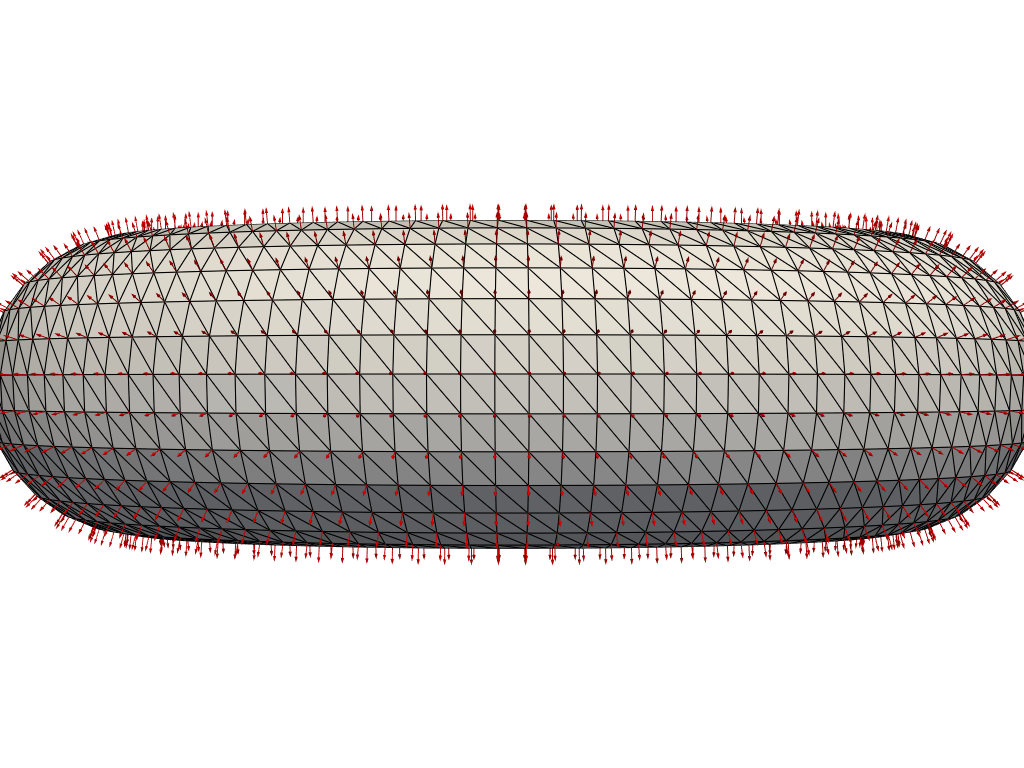

/usr/users/JIC_a5/tomkinsm/.local/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:37: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/usr/users/JIC_a5/tomkinsm/.local/lib/python3.10/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


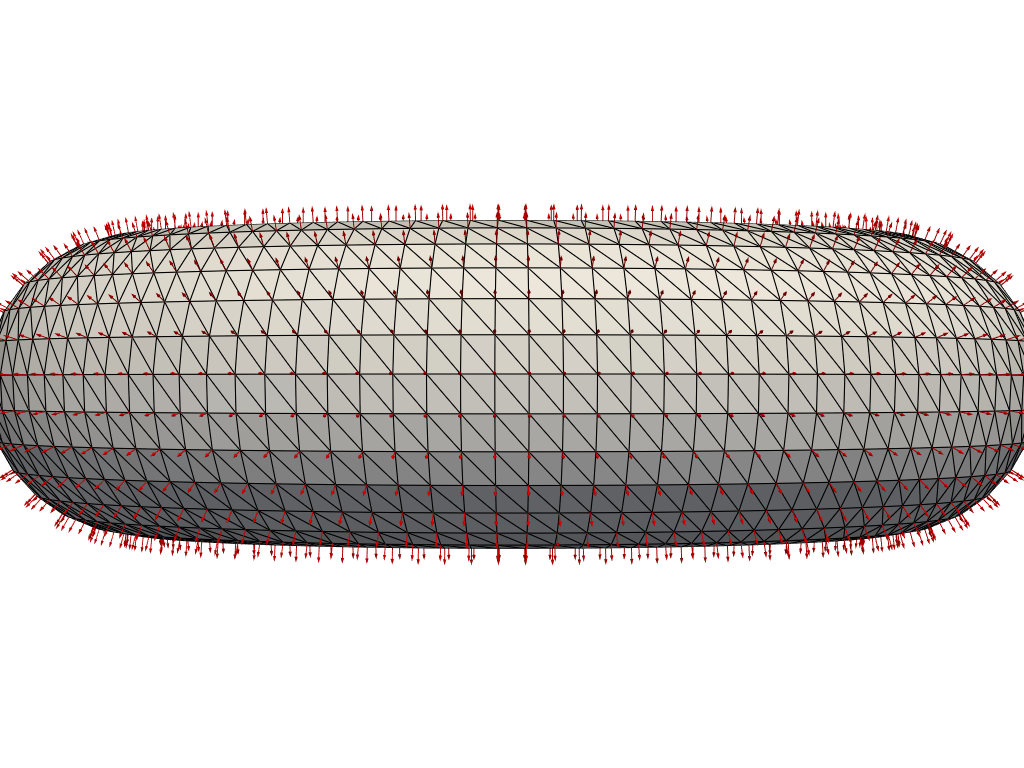

/usr/users/JIC_a5/tomkinsm/.local/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:37: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/usr/users/JIC_a5/tomkinsm/.local/lib/python3.10/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


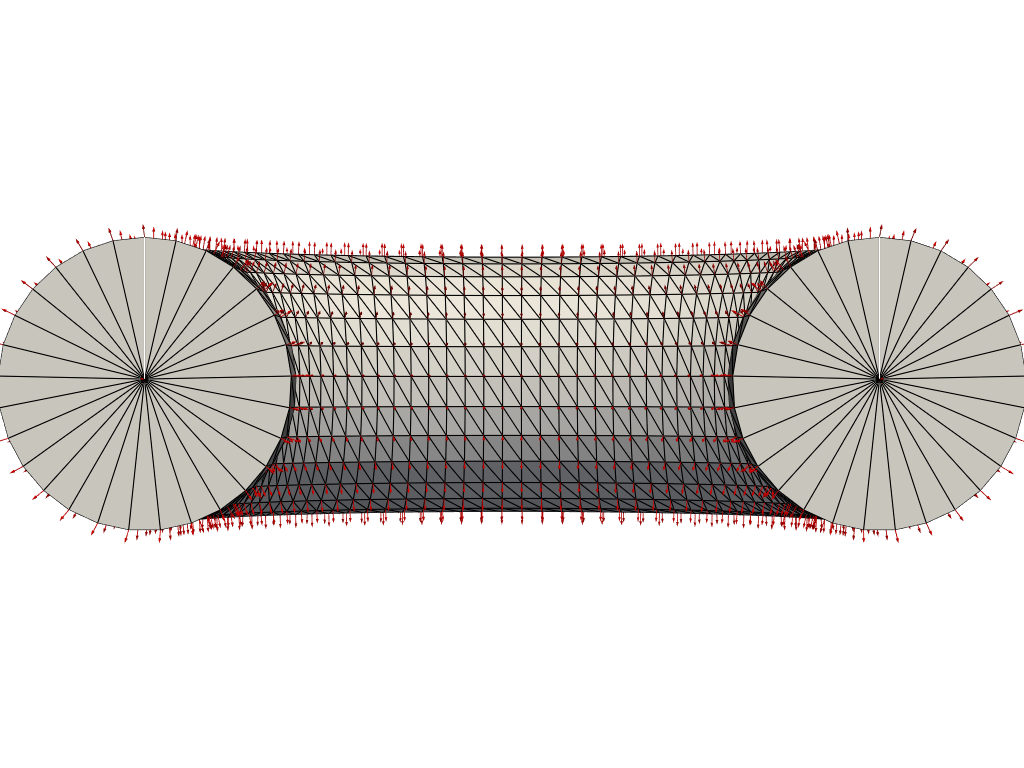

In [50]:
import pyvista as pv

# Assuming 'mesh' is your PolyData object
mesh = pv.read("single_cell.ply")

# Print available point data arrays
print("Available point data arrays:", mesh.point_data.keys())

# Clean the mesh to remove any non-manifold edges or other issues
mesh = mesh.clean()

# Compute normals for the entire mesh
mesh = mesh.compute_normals(auto_orient_normals=True)

# Print available point data arrays after computing normals
print("Available point data arrays after computing normals:", mesh.point_data.keys())

# Get the normals
normals = mesh.point_data['Normals']

# Create a plotter object
plotter = pv.Plotter()

# Add the mesh and arrows to the plotter
plotter.add_mesh(mesh, color='white', show_edges=True)
plotter.add_arrows(mesh.points, normals * 0.1, color='red')  # Scale normals for visibility

# Set custom camera positions to view the end caps
# Assuming the end caps are along the Z-axis
plotter.camera_position = [(0, 0, 10), (0, 0, 0), (0, 1, 0)]  # View from +Z
plotter.show(screenshot="mesh_view_end_cap_positive_z.png")

plotter.camera_position = [(0, 0, -10), (0, 0, 0), (0, 1, 0)]  # View from -Z
plotter.show(screenshot="mesh_view_end_cap_negative_z.png")

# Show the final plot
plotter.show()

## Boundary joint 19176 adjoins three facets 14451, 14422, and 14450


In [45]:
!python3 -m pip install --upgrade trame vtk

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 MB 50.9 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: vtk
    Found existing installation: vtk 9.3.1
    Not uninstalling vtk at /usr/users/JIC_a5/tomkinsm/.local/lib/python3.10/site-packages, outside environment /usr
    Can't uninstall 'vtk'. No files were found to uninstall.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyvista 0.44.2 requires vtk<9.4.0, but you have vtk 9.4.1 which is incompatible.


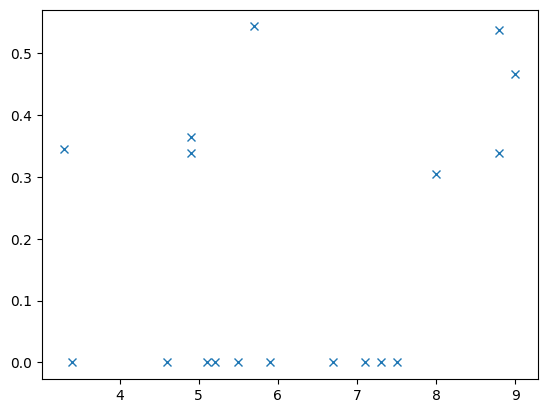

In [3]:
w1 = [4.9, 5.7, 4.6, 5.2, 4.9, 8.8, 9, 8, 3.3, 6.7, 7.5, 8.8, 5.9, 5.5, 3.4, 7.1, 7.3, 5.1]
w2 = [0.364, 0.543, 0, 0, 0.338, 0.339, 0.466, 0.304, 0.345, 0, 0, 0.537, 0, 0, 0, 0, 0 ,0]

import matplotlib.pyplot as plt

plt.plot(w1, w2, "x")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import tifffile as tiff

# Load the confocal stack
confocal_stack = tiff.imread("/Users/tomkinsm/Downloads/Onion meshes 2/Ac_DA_1_2/Ac_DA_1_2_2023_09_11__13_18_06_Out.tif")

# Display the confocal stack
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# Create a 3D voxel plot
ax.voxels(confocal_stack, edgecolor="k")

plt.show()


KeyboardInterrupt: 

In [1]:
import numpy as np
import tifffile as tiff
from PIL import Image, ImageEnhance
import os

# Load the TIFF stack
tif_path = "/Users/tomkinsm/Downloads/Onion meshes 2/Ac_DA_1_2/Ac_DA_1_2_2023_09_11__13_18_06_Out.tif"
confocal_stack = tiff.imread(tif_path)

# Create an output directory for the PNG files
output_dir = "output_pngs"
os.makedirs(output_dir, exist_ok=True)

# Function to increase contrast
def increase_contrast(image, factor=2.0):
    pil_image = Image.fromarray(image)
    enhancer = ImageEnhance.Contrast(pil_image)
    enhanced_image = enhancer.enhance(factor)
    return enhanced_image

# Process each layer and save as PNG
for i, layer in enumerate(confocal_stack):
    # Normalize the layer to 8-bit
    layer_normalized = ((layer - np.min(layer)) / (np.max(layer) - np.min(layer)) * 255).astype(np.uint8)
    
    # Increase contrast
    enhanced_image = increase_contrast(layer_normalized)
    
    # Save the enhanced image as PNG
    output_path = os.path.join(output_dir, f"layer_{i:03d}.png")
    enhanced_image.save(output_path)

print(f"Saved {len(confocal_stack)} layers as PNG files in '{output_dir}'")




Saved 76 layers as PNG files in 'output_pngs'


In [7]:
import numpy as np
import tifffile as tiff
from PIL import Image, ImageEnhance
import imageio

# Load the TIFF stack
tif_path = "/Users/tomkinsm/Downloads/Onion meshes 2/Ac_DA_1_2/Ac_DA_1_2_2023_09_11__13_18_06_Out.tif"
confocal_stack = tiff.imread(tif_path)

# Function to increase contrast
def increase_contrast(image, factor=2.0):
    pil_image = Image.fromarray(image)
    enhancer = ImageEnhance.Contrast(pil_image)
    enhanced_image = enhancer.enhance(factor)
    return np.array(enhanced_image)

# Process each layer and increase contrast
enhanced_stack = []
for layer in confocal_stack:
    # Normalize the layer to 8-bit
    layer_normalized = ((layer - np.min(layer)) / (np.max(layer) - np.min(layer)) * 255).astype(np.uint8)
    
    # Increase contrast
    enhanced_image = increase_contrast(layer_normalized)
    
    # Append the enhanced image to the stack
    enhanced_stack.append(enhanced_image)

# Convert the enhanced stack to a numpy array
enhanced_stack = np.stack(enhanced_stack, axis=0)

# Ensure the stack has the correct shape (depth, height, width)
if enhanced_stack.ndim == 4:
    enhanced_stack = enhanced_stack.squeeze(axis=0)

# Save the enhanced stack as a 3D DDS texture
dds_path = "confocal_stack.dds"
imageio.volwrite(dds_path, enhanced_stack, format='DDS')

print(f"Saved the confocal stack as a 3D DDS texture in '{dds_path}'")

TypeError: Cannot handle this data type: (1, 1, 488), |u1